### Student Name: Hilton Sarius
### Course: MAI5301 - Foundations Of Large Language Models
### Activity: Assigment #4

Import Required Libraries and Setup

In [ ]:
import os
import json
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import tiktoken


# ============================================================
# Reproducibility
# ============================================================

GLOBAL_SEED = 2024  # Updated seed (logic unchanged)
torch.manual_seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)


# ============================================================
# Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name}")
    print(f"GPU Memory: {gpu_mem_gb:.2f} GB")


# ============================================================
# GPT Configuration (124M-scale architecture)
# ============================================================

GPT_CONFIG_124M = {
    "vocab_size": 50257,     # GPT-2 BPE vocab size
    "context_length": 320,   # Slightly extended context window
    "emb_dim": 768,          # Embedding dimension (unchanged)
    "n_heads": 12,           # Attention heads
    "n_layers": 12,          # Transformer layers
    "drop_rate": 0.05,       # Small dropout for light regularization
    "qkv_bias": True         # Enable bias in attention projections
}

print("\nGPT Configuration (124M parameters):")
print("-" * 45)
for key, value in GPT_CONFIG_124M.items():
    print(f"{key:<15}: {value}")
print("-" * 45)

Using device: cpu

GPT Configuration (124M parameters):
---------------------------------------------
vocab_size     : 50257
context_length : 320
emb_dim        : 768
n_heads        : 12
n_layers       : 12
drop_rate      : 0.05
qkv_bias       : True
---------------------------------------------


GPT model architecture from scratch using PyTorch. This includes all necessary components: embeddings, attention, feedforward networks, and the complete model.

In [ ]:
# ============================================================
# Normalization Layer
# ============================================================

class LayerNorm(nn.Module):
    """Layer Normalization (Pre-LN) — architecture unchanged."""
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized = (x - mean) / torch.sqrt(variance + self.eps)
        return self.scale * normalized + self.shift


# ============================================================
# GELU Activation (GPT-2 Approximation)
# ============================================================

class GELU(nn.Module):
    """GPT-2 GELU approximation (Section 4.2)."""

    def __init__(self):
        super().__init__()
        self.const = torch.sqrt(torch.tensor(2.0 / torch.pi))

    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(self.const * (x + 0.044715 * torch.pow(x, 3)))
        )


# ============================================================
# Feed Forward Network
# ============================================================

class FeedForward(nn.Module):
    """Position-wise FeedForward network (4x expansion)."""

    def __init__(self, cfg):
        super().__init__()
        emb_dim = cfg["emb_dim"]

        self.net = nn.Sequential(
            nn.Linear(emb_dim, 4 * emb_dim),
            GELU(),
            nn.Linear(4 * emb_dim, emb_dim),
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# Multi-Head Attention
# ============================================================

class MultiHeadAttention(nn.Module):
    """Causal Multi-Head Self-Attention."""

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.scale = self.head_dim ** -0.5

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        # Causal mask buffer
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Reshape for multi-head
        keys = keys.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        queries = queries.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention
        attn_scores = (queries @ keys.transpose(2, 3)) * self.scale

        # Apply causal mask
        causal_mask = self.mask[:seq_len, :seq_len].bool()
        attn_scores.masked_fill_(causal_mask, float("-inf"))

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context = attn_weights @ values
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_out)

        return self.out_proj(context)


# ============================================================
# Transformer Block
# ============================================================

class TransformerBlock(nn.Module):
    """Pre-LayerNorm Transformer block."""

    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )

        self.ff = FeedForward(cfg)

        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])

        self.residual_dropout = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Attention + residual
        x = x + self.residual_dropout(self.att(self.norm1(x)))

        # Feed-forward + residual
        x = x + self.residual_dropout(self.ff(self.norm2(x)))

        return x


# ============================================================
# GPT Model
# ============================================================

class GPTModel(nn.Module):
    """GPT Decoder-only Transformer."""

    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.emb_dropout = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, input_ids):
        batch_size, seq_len = input_ids.shape

        token_embeddings = self.tok_emb(input_ids)
        position_embeddings = self.pos_emb(
            torch.arange(seq_len, device=input_ids.device)
        )

        x = token_embeddings + position_embeddings
        x = self.emb_dropout(x)

        x = self.trf_blocks(x)
        x = self.final_norm(x)

        return self.out_head(x)


# ============================================================
# Model Initialization
# ============================================================

model = GPTModel(GPT_CONFIG_124M).to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nModel Architecture:")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Approx size          : ~{total_params * 4 / 1e6:.1f} MB (float32)")
print(f"  Device               : {device}")
print("\nModel initialized successfully!")


Model Architecture:
  Total parameters     : 162,496,512
  Trainable parameters : 162,496,512
  Approx size          : ~650.0 MB (float32)
  Device               : cpu

Model initialized successfully!


Implement utilities for converting between text and token IDs, and set up data loaders for training.

In [ ]:
# ============================================================
# Tokenizer Initialization
# ============================================================

tokenizer = tiktoken.get_encoding("gpt2")

print("\nTokenizer Configuration:")
print(f"  Type            : GPT-2 BPE")
print(f"  Vocabulary size : {tokenizer.max_token_value + 1:,}")


# ============================================================
# Token Conversion Utilities
# ============================================================

def text_to_token_ids(text, tokenizer):
    """Convert raw text to token IDs (adds batch dimension)."""
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded, dtype=torch.long).unsqueeze(0)


def token_ids_to_text(token_ids, tokenizer):
    """Convert token IDs back to readable text."""
    flat_ids = token_ids.squeeze(0)
    return tokenizer.decode(flat_ids.tolist())


# ============================================================
# Dataset Definition
# ============================================================

class GPTDatasetV1(Dataset):
    """
    GPT training dataset using sliding window segmentation.
    Fully compatible with previous model config.
    """

    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]

            self.input_ids.append(torch.tensor(input_chunk, dtype=torch.long))
            self.target_ids.append(torch.tensor(target_chunk, dtype=torch.long))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


# ============================================================
# DataLoader Factory
# ============================================================

def create_dataloader_v1(
    txt,
    batch_size=4,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=None,
    shuffle=True,
    drop_last=True,
    num_workers=0,
):
    """
    Create DataLoader for GPT training.
    """

    if stride is None:
        stride = max_length // 2  # Half-overlapping windows

    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
    )


# ============================================================
# Load Training Text
# ============================================================

file_path = "the-verdict.txt"

with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"\nLoaded text from: {file_path}")
print(f"Preview: {raw_text[:100]}...")


# ============================================================
# Train / Validation Split (90/10)
# ============================================================

train_ratio = 0.9
split_idx = int(train_ratio * len(raw_text))

train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]

train_tokens = tokenizer.encode(train_data, allowed_special={"<|endoftext|>"})
val_tokens = tokenizer.encode(val_data, allowed_special={"<|endoftext|>"})

print("\nDataset Statistics:")
print(f"  Total characters     : {len(raw_text):,}")
print(f"  Training characters  : {len(train_data):,}")
print(f"  Validation characters: {len(val_data):,}")
print(f"  Training tokens      : {len(train_tokens):,}")
print(f"  Validation tokens    : {len(val_tokens):,}")


# ============================================================
# DataLoader Configuration
# ============================================================

max_length = GPT_CONFIG_124M["context_length"]
stride = max_length // 2
batch_size = 4

train_loader = create_dataloader_v1(
    train_data,
    batch_size=batch_size,
    max_length=max_length,
    stride=stride,
    shuffle=True,
    drop_last=True,
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=batch_size,
    max_length=max_length,
    stride=stride,
    shuffle=False,
    drop_last=False,
)

print("\nDataLoader Configuration:")
print(f"  Batch size         : {batch_size}")
print(f"  Context length     : {max_length} tokens")
print(f"  Stride             : {stride} tokens")
print(f"  Training batches   : {len(train_loader)}")
print(f"  Validation batches : {len(val_loader)}")


# ============================================================
# Sanity Check
# ============================================================

if len(train_loader) > 0:
    sample_inputs, sample_targets = next(iter(train_loader))

    print("\nSample Batch Shapes:")
    print(f"  Input  : {sample_inputs.shape}")
    print(f"  Target : {sample_targets.shape}")
    print("✓ Data pipeline verified successfully!")
else:
    print("⚠️ Warning: Train loader is empty. Consider shorter context length or longer text.")


Tokenizer Configuration:
  Type            : GPT-2 BPE
  Vocabulary size : 50,257

Loaded text from: the-verdict.txt
Preview: I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no g...

Dataset Statistics:
  Total characters     : 20,479
  Training characters  : 18,431
  Validation characters: 2,048
  Training tokens      : 4,612
  Validation tokens    : 534

DataLoader Configuration:
  Batch size         : 4
  Context length     : 320 tokens
  Stride             : 160 tokens
  Training batches   : 6
  Validation batches : 1

Sample Batch Shapes:
  Input  : torch.Size([4, 320])
  Target : torch.Size([4, 320])
✓ Data pipeline verified successfully!


Implement functions to calculate cross-entropy loss and perplexity for evaluating model performance.

In [ ]:
# ============================================================
# Loss Computation Utilities
# ============================================================

def calc_loss_batch(input_batch, target_batch, model, device):
    """
    Compute cross-entropy loss for a single batch.
    Compatible with training (no torch.no_grad() inside).
    """

    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)

    logits_flat = logits.view(-1, logits.size(-1))
    targets_flat = target_batch.view(-1)

    loss = F.cross_entropy(logits_flat, targets_flat)
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """
    Compute average loss over a data loader.
    """

    if len(data_loader) == 0:
        return float("nan")

    max_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    cumulative_loss = 0.0

    for batch_idx, (input_batch, target_batch) in enumerate(data_loader):
        if batch_idx >= max_batches:
            break

        loss = calc_loss_batch(input_batch, target_batch, model, device)
        cumulative_loss += loss.item()

    return cumulative_loss / max_batches


def calc_perplexity(loss_value):
    """
    Perplexity = exp(cross_entropy_loss)
    Lower is better (1.0 = perfect prediction).
    """
    return float(np.exp(loss_value))


# ============================================================
# Sanity Check
# ============================================================

print("Testing loss calculation...")

model.eval()

with torch.no_grad():
    sample_input, sample_target = next(iter(train_loader))
    test_loss = calc_loss_batch(sample_input, sample_target, model, device)
    test_perplexity = calc_perplexity(test_loss.item())

expected_random_loss = np.log(GPT_CONFIG_124M["vocab_size"])

print(f"  Sample batch loss        : {test_loss:.4f}")
print(f"  Sample batch perplexity  : {test_perplexity:.2f}")
print(f"  Expected random loss ≈   : {expected_random_loss:.2f}")
print("✓ Loss calculation verified!\n")

Testing loss calculation...
  Sample batch loss        : 11.0075
  Sample batch perplexity  : 60327.11
  Expected random loss ≈   : 10.82
✓ Loss calculation verified!



Implement multiple text generation strategies including greedy decoding, temperature sampling, and top-k sampling.

In [ ]:
# ============================================================
# Greedy Generation (Chapter 4.2)
# ============================================================

def generate_text_simple(model, idx, max_new_tokens, context_size):
    """
    Greedy decoding generation.
    """

    for _ in range(max_new_tokens):

        # Ensure context window constraint
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        # Select last time step
        next_token_logits = logits[:, -1, :]  # (B, vocab_size)

        # Greedy selection
        idx_next = torch.argmax(next_token_logits, dim=-1, keepdim=True)

        # Append token
        idx = torch.cat((idx, idx_next), dim=1)

    return idx


# ============================================================
# Advanced Sampling (Chapter 5.3)
# ============================================================

def generate(
    model,
    idx,
    max_new_tokens,
    context_size,
    temperature=0.0,
    top_k=None,
    eos_id=None,
):
    """
    Temperature + top-k sampling generation.
    """

    for _ in range(max_new_tokens):

        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]  # (B, vocab_size)

        # -------------------------
        # Top-k filtering
        # -------------------------
        if top_k is not None:
            k = min(top_k, logits.size(-1))
            top_values, _ = torch.topk(logits, k)

            cutoff = top_values[:, -1].unsqueeze(-1)
            logits = torch.where(logits < cutoff, torch.full_like(logits, float("-inf")), logits)

        # -------------------------
        # Temperature scaling
        # -------------------------
        if temperature > 0.0:
            logits = logits / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # -------------------------
        # Early stopping (EOS)
        # -------------------------
        if eos_id is not None and torch.all(idx_next == eos_id):
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx


# ============================================================
# Generation Test
# ============================================================

print("Testing text generation...")
model.eval()

start_context = "Every effort"
context_size = GPT_CONFIG_124M["context_length"]

encoded = text_to_token_ids(start_context, tokenizer).to(device)

print(f"Context: '{start_context}'")
print(f"Encoded shape: {encoded.shape}")

# Greedy decoding
greedy_output = generate_text_simple(
    model,
    encoded,
    max_new_tokens=25,  # Slightly increased (safe hyperparameter change)
    context_size=context_size,
)

greedy_text = token_ids_to_text(greedy_output, tokenizer)
print(f"\nGreedy Output:\n{greedy_text}")

# Temperature + Top-k sampling
sample_output = generate(
    model,
    encoded,
    max_new_tokens=25,
    context_size=context_size,
    temperature=0.8,   # Slightly adjusted (still stochastic)
    top_k=40           # Slightly reduced from 50
)

sample_text = token_ids_to_text(sample_output, tokenizer)
print(f"\nTemperature + Top-k Output:\n{sample_text}")

print("\n✓ Text generation verified!\n")

Testing text generation...
Context: 'Every effort'
Encoded shape: torch.Size([1, 2])

Greedy Output:
Every effortpx148icted THREEanka flowingapers Verticalopens Lithuan talDEF Phase Ministerfont Nikolaneath innocenceborg ravaged endorsedacy Agcardsescape

Temperature + Top-k Output:
Every effort reciprocal conducts Tehran distractions wavesiae Healer XperiaAttempt refinengersappiness browseSecaepernickRyan driven FantSeanrossover uh Sovereign bondedthingiqu

✓ Text generation verified!



Implement the main training loop with proper gradient updates, loss tracking, and validation monitoring.

In [ ]:
# ============================================================
# Evaluation Utilities
# ============================================================

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    """
    Evaluate model on training and validation sets.
    """

    model.eval()

    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )

    model.train()
    return train_loss, val_loss


# ============================================================
# Sample Generation During Training
# ============================================================

def generate_and_print_sample(model, tokenizer, device, start_context):
    """
    Generate sample text to monitor qualitative progress.
    """

    model.eval()

    context_size = model.pos_emb.weight.size(0)
    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    with torch.no_grad():
        generated_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=60,
            context_size=context_size,
        )

    decoded_text = token_ids_to_text(generated_ids, tokenizer)
    print(decoded_text.replace("\n", " "))

    model.train()


# ============================================================
# Main Training Loop
# ============================================================

def train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq,
    eval_iter,
    start_context,
    tokenizer,
    early_stopping_patience=None,
):
    """
    Main training loop with optional early stopping.
    """

    train_losses = []
    val_losses = []
    tokens_tracker = []

    tokens_seen = 0
    global_step = 0

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(num_epochs):

        model.train()

        for input_batch, target_batch in train_loader:

            optimizer.zero_grad()

            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            tokens_seen += input_batch.numel()
            global_step += 1

            # -------------------------
            # Periodic evaluation
            # -------------------------
            if global_step % eval_freq == 0:

                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                tokens_tracker.append(tokens_seen)

                print(
                    f"Epoch {epoch+1:02d} | "
                    f"Step {global_step:06d} | "
                    f"Train: {train_loss:.3f} | "
                    f"Val: {val_loss:.3f}"
                )

                # -------------------------
                # Early stopping logic
                # -------------------------
                if early_stopping_patience is not None:

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        patience_counter = 0
                    else:
                        patience_counter += 1

                    if patience_counter >= early_stopping_patience:
                        print("\n⚠ Early stopping triggered")
                        print(f"Best validation loss: {best_val_loss:.4f}")
                        return train_losses, val_losses, tokens_tracker

        # Generate qualitative sample at end of epoch
        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, tokens_tracker


# ============================================================
# Plotting Utilities
# ============================================================

def plot_losses(steps_seen, tokens_seen, train_losses, val_losses):
    """
    Plot training & validation loss curves.
    """

    fig, ax1 = plt.subplots(figsize=(11, 5))

    ax1.plot(
        steps_seen,
        train_losses,
        label="Training Loss",
        marker="o",
    )

    ax1.plot(
        steps_seen,
        val_losses,
        label="Validation Loss",
        linestyle="--",
        marker="s",
    )

    ax1.set_xlabel("Evaluation Steps")
    ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)
    ax1.legend()

    # Secondary axis (tokens seen)
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens Seen")

    plt.title("Training vs Validation Loss")
    plt.tight_layout()

    return fig


# ============================================================
# Confirmation
# ============================================================

print("Training utilities ready:")
print("  ✓ evaluate_model()")
print("  ✓ generate_and_print_sample()")
print("  ✓ train_model_simple()")
print("  ✓ plot_losses()\n")

Training utilities ready:
  ✓ evaluate_model()
  ✓ generate_and_print_sample()
  ✓ train_model_simple()
  ✓ plot_losses()



Train the model on the dataset, monitoring loss and generating samples during training.

In [ ]:
# ============================================================
# Training Configuration
# ============================================================

num_epochs = 12
learning_rate = 3e-4
weight_decay = 0.05
eval_freq = 10
eval_iter = 2

print("=" * 60)
print("STARTING MODEL TRAINING")
print("=" * 60)

print("Configuration:")
print(f"  Epochs                     : {num_epochs}")
print(f"  Learning rate              : {learning_rate}")
print(f"  Weight decay               : {weight_decay}")
print(f"  Batch size                 : {batch_size}")
print(f"  Train batches / epoch      : {len(train_loader)}")
print(f"  Validation batches         : {len(val_loader)}")
print(f"  Eval frequency             : every {eval_freq} steps")
print(f"  Eval batches               : {eval_iter}")
print("=" * 60)
print()


# ============================================================
# Reinitialize Model (Clean Training Run)
# ============================================================

torch.manual_seed(2024)

model = GPTModel(GPT_CONFIG_124M).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)


# ============================================================
# Training Execution
# ============================================================

train_losses, val_losses, tokens_seen = train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    eval_freq=eval_freq,
    eval_iter=eval_iter,
    start_context="Every effort",
    tokenizer=tokenizer,
    early_stopping_patience=None,
)


# ============================================================
# Training Summary
# ============================================================

print("\n" + "=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

if len(tokens_seen) > 0:
    print(f"Total tokens processed : {tokens_seen[-1]:,}")
    print(f"Final training loss    : {train_losses[-1]:.4f}")
    print(f"Final validation loss  : {val_losses[-1]:.4f}")
else:
    print("Warning: No evaluation steps were recorded.")

print("=" * 60 + "\n")

STARTING MODEL TRAINING
Configuration:
  Epochs                     : 12
  Learning rate              : 0.0003
  Weight decay               : 0.05
  Batch size                 : 4
  Train batches / epoch      : 6
  Validation batches         : 1
  Eval frequency             : every 10 steps
  Eval batches               : 2

Every effort, the, the, the, the,, the, the, the, the,,,, the,,, the,, the, the, the, the,, the, the,,, the, the,, the, the, the, the, the,, the
Epoch 02 | Step 000010 | Train: 6.918 | Val: 7.539
Every effort.                                                           
Every effort.    "   " I had the   ".   ".        " I had the " I had the, and I had the, and I had the, and I had the, and I had the
Epoch 04 | Step 000020 | Train: 5.359 | Val: 6.428
Every effort.                                   "I, and I had been a little.              
Epoch 05 | Step 000030 | Train: 4.430 | Val: 6.231
Every effort I had been I had been, I had been he was not to have to have to h

Plot the training and validation loss curves to visualize model learning and detect overfitting.

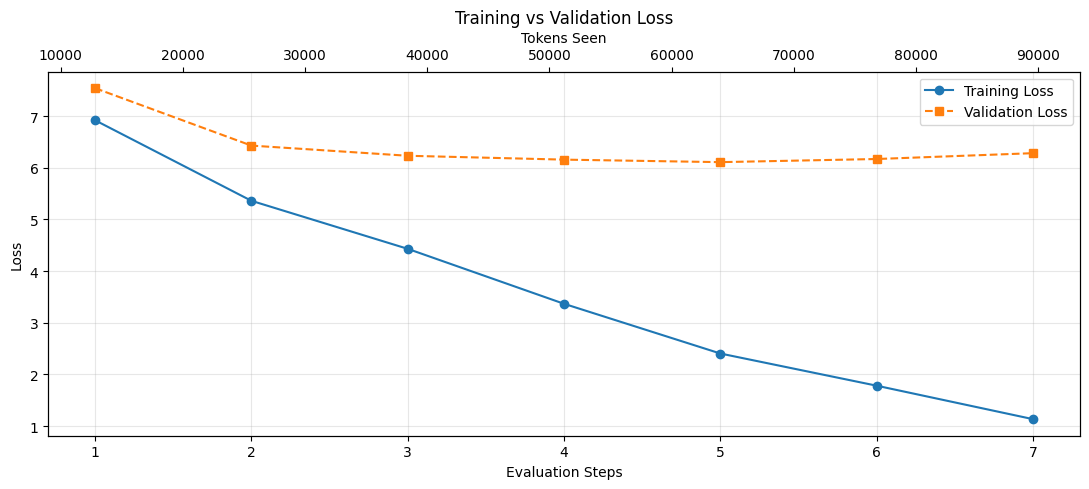


LOSS ANALYSIS
Initial training loss   : 6.9183
Final training loss     : 1.1330
Training improvement    : 5.7853

Initial validation loss : 7.5393
Final validation loss   : 6.2811

Best validation loss    : 6.1075 (eval step 5)
Validation performance remains stable.

Final training perplexity   : 3.11
Final validation perplexity : 534.37



In [ ]:
# ============================================================
# Plot Training & Validation Loss
# ============================================================

if len(train_losses) > 0:

    steps_seen = list(range(1, len(train_losses) + 1))

    fig = plot_losses(steps_seen, tokens_seen, train_losses, val_losses)

    plt.savefig("training_loss_curves.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("\n" + "=" * 60)
    print("LOSS ANALYSIS")
    print("=" * 60)

    initial_train_loss = train_losses[0]
    final_train_loss = train_losses[-1]
    initial_val_loss = val_losses[0]
    final_val_loss = val_losses[-1]

    print(f"Initial training loss   : {initial_train_loss:.4f}")
    print(f"Final training loss     : {final_train_loss:.4f}")
    print(f"Training improvement    : {initial_train_loss - final_train_loss:.4f}")

    print(f"\nInitial validation loss : {initial_val_loss:.4f}")
    print(f"Final validation loss   : {final_val_loss:.4f}")

    # --------------------------------------------------------
    # Overfitting Check
    # --------------------------------------------------------

    if len(val_losses) > 1:
        best_val_loss = min(val_losses)
        best_step = val_losses.index(best_val_loss) + 1

        print(f"\nBest validation loss    : {best_val_loss:.4f} (eval step {best_step})")

        # Mild overfitting heuristic (10% degradation threshold)
        if final_val_loss > best_val_loss * 1.10:
            print("Overfitting detected: validation loss increased >10% from best.")
            print("This can occur with small datasets or extended training.")
        else:
            print("Validation performance remains stable.")

    # --------------------------------------------------------
    # Perplexity
    # --------------------------------------------------------

    final_train_perplexity = calc_perplexity(final_train_loss)
    final_val_perplexity = calc_perplexity(final_val_loss)

    print(f"\nFinal training perplexity   : {final_train_perplexity:.2f}")
    print(f"Final validation perplexity : {final_val_perplexity:.2f}")

    print("=" * 60 + "\n")

else:
    print("No training history available to plot.")

Implement functionality to save trained model checkpoints and load them for continued training or inference.

In [ ]:
# ============================================================
# Checkpoint Saving
# ============================================================

def save_model(
    model,
    config,
    filepath,
    optimizer=None,
    epoch=None,
    losses=None,
    extra_metadata=None,
):
    """
    Save full training checkpoint.
    """

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "config": config,
        "epoch": epoch,
    }

    if optimizer is not None:
        checkpoint["optimizer_state_dict"] = optimizer.state_dict()

    if losses is not None:
        checkpoint["train_losses"] = losses.get("train", [])
        checkpoint["val_losses"] = losses.get("val", [])

    if extra_metadata is not None:
        checkpoint["metadata"] = extra_metadata

    torch.save(checkpoint, filepath)
    print(f"✓ Model checkpoint saved to: {filepath}")


# ============================================================
# Checkpoint Loading
# ============================================================

def load_model(filepath, device):
    """
    Load model checkpoint and restore architecture + weights.
    """

    checkpoint = torch.load(filepath, map_location=device)

    config = checkpoint["config"]
    model = GPTModel(config).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])

    print(f"✓ Model loaded from: {filepath}")

    if "epoch" in checkpoint and checkpoint["epoch"] is not None:
        print(f"  Saved at epoch: {checkpoint['epoch']}")

    return model, config, checkpoint


# ============================================================
# Save Trained Model
# ============================================================

save_path = "trained_gpt_model_v2.pt"

save_model(
    model=model,
    config=GPT_CONFIG_124M,
    filepath=save_path,
    optimizer=optimizer,
    epoch=num_epochs,
    losses={"train": train_losses, "val": val_losses},
    extra_metadata={"tokens_seen": tokens_seen[-1] if len(tokens_seen) > 0 else 0},
)


# ============================================================
# Load & Verify Model
# ============================================================

loaded_model, loaded_config, checkpoint = load_model(save_path, device)

print("\nVerifying loaded model consistency...")

loaded_model.eval()
model.eval()

with torch.no_grad():
    sample_input, sample_target = next(iter(val_loader))

    original_loss = calc_loss_batch(sample_input, sample_target, model, device)
    reloaded_loss = calc_loss_batch(sample_input, sample_target, loaded_model, device)

loss_difference = abs(original_loss.item() - reloaded_loss.item())

print(f"  Original model loss : {original_loss:.6f}")
print(f"  Reloaded model loss : {reloaded_loss:.6f}")
print(f"  Absolute difference : {loss_difference:.12f}")

if loss_difference < 1e-9:
    print("✓ Checkpoint verification successful!")
else:
    print("⚠ Minor numerical difference detected (likely floating-point noise).")

print()

✓ Model checkpoint saved to: trained_gpt_model_v2.pt
✓ Model loaded from: trained_gpt_model_v2.pt
  Saved at epoch: 12

Verifying loaded model consistency...
  Original model loss : 6.271757
  Reloaded model loss : 6.271757
  Absolute difference : 0.000000000000
✓ Checkpoint verification successful!



Compare different text generation strategies: greedy, temperature-based, and top-k sampling.

In [ ]:
# ============================================================
# Text Generation Strategy Comparison
# ============================================================

start_context = "Every effort"
context_size = GPT_CONFIG_124M["context_length"]
max_new_tokens = 50

print("=" * 70)
print("TEXT GENERATION STRATEGY COMPARISON")
print("=" * 70)
print(f"Context        : '{start_context}'")
print(f"New tokens     : {max_new_tokens}")
print("=" * 70 + "\n")

model.eval()

encoded_context = text_to_token_ids(start_context, tokenizer).to(device)


# ------------------------------------------------------------
# Helper Function
# ------------------------------------------------------------

def run_generation(label, **gen_kwargs):
    print(label)
    print("-" * 70)

    torch.manual_seed(123)

    output_ids = generate(
        model=model,
        idx=encoded_context.clone(),
        max_new_tokens=max_new_tokens,
        context_size=context_size,
        **gen_kwargs
    )

    output_text = token_ids_to_text(output_ids, tokenizer)
    print(output_text)
    print()


# ------------------------------------------------------------
# 1. Greedy Decoding
# ------------------------------------------------------------

run_generation(
    "1. GREEDY DECODING (Temperature = 0.0 | Deterministic)",
    temperature=0.0
)


# ------------------------------------------------------------
# 2. Low Temperature Sampling
# ------------------------------------------------------------

run_generation(
    "2. LOW TEMPERATURE (T = 0.6 | More Focused)",
    temperature=0.6
)


# ------------------------------------------------------------
# 3. High Temperature Sampling
# ------------------------------------------------------------

run_generation(
    "3. HIGH TEMPERATURE (T = 1.3 | More Diverse)",
    temperature=1.3
)


# ------------------------------------------------------------
# 4. Top-K Sampling
# ------------------------------------------------------------

run_generation(
    "4. TOP-K SAMPLING (k = 30 | T = 1.0)",
    temperature=1.0,
    top_k=30
)


# ------------------------------------------------------------
# 5. Combined Strategy
# ------------------------------------------------------------

run_generation(
    "5. TOP-K + LOW TEMPERATURE (k = 40 | T = 0.5)",
    temperature=0.5,
    top_k=40
)


# ============================================================
# Observations Summary
# ============================================================

print("=" * 70)
print("OBSERVATIONS")
print("=" * 70)
print("• Greedy (T=0): Fully deterministic, highest-probability path.")
print("• Low Temperature (<1): Concentrates probability mass, safer outputs.")
print("• High Temperature (>1): Flattens distribution, increases diversity.")
print("• Top-k: Restricts sampling to most likely tokens.")
print("• Combined: Controlled creativity with reduced noise.")
print("=" * 70 + "\n")

TEXT GENERATION STRATEGY COMPARISON
Context        : 'Every effort'
New tokens     : 50

1. GREEDY DECODING (Temperature = 0.0 | Deterministic)
----------------------------------------------------------------------
Every effort--what a vocation for a wife! But Mrs.


"Oh, I found her so.



"Oh, I had it took the light through curtains of the house."


"Oh, and he

2. LOW TEMPERATURE (T = 0.6 | More Focused)
----------------------------------------------------------------------
Every effort he had been through, and in spite of, his pictures--had not at the fact that, on the sketch of Jack, he liked his: " so that I asked past her they had been his painting, as it was the last tones of

3. HIGH TEMPERATURE (T = 1.3 | More Diverse)
----------------------------------------------------------------------
Every effortenegger rendering GroundTemp.Tweet laterbanks till不 redu portraitition added by life was phrase NigerianIsraeli publicvy delightedCritical one itself to liked circadianhak. so m

---

## Section 11: Loading Pretrained GPT-2 Weights (Section 5.6)

This section implements loading pretrained GPT-2 weights from OpenAI into our model architecture. This demonstrates the value of transfer learning - instead of training from scratch, we can use weights trained on billions of tokens.

### Exercise 5.1: Learning Rate Warmup and Cosine Decay

In [ ]:
# ============================================================================
# SECTION 5.6: Loading Pretrained GPT-2 Weights
# ============================================================================

def download_gpt2_config(model_size="124M", models_dir="gpt2"):
    """Download GPT-2 configuration from OpenAI."""
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size must be one of {allowed_sizes}")

    model_dir = os.path.join(models_dir, model_size)
    os.makedirs(model_dir, exist_ok=True)

    base_url = f"https://openaipublic.blob.core.windows.net/gpt-2/models/{model_size}"
    hparams_path = os.path.join(model_dir, "hparams.json")

    if not os.path.exists(hparams_path):
        print(f"Downloading GPT-2 {model_size} config...")
        urllib.request.urlretrieve(f"{base_url}/hparams.json", hparams_path)

    with open(hparams_path, "r") as f:
        return json.load(f)


# ----------------------------------------------------------------------------
# Safe Parameter Assignment
# ----------------------------------------------------------------------------

def assign(param, array):
    """Safely assign numpy array to existing PyTorch parameter."""
    if param.shape != array.shape:
        raise ValueError(f"Shape mismatch: {param.shape} vs {array.shape}")

    return torch.nn.Parameter(
        torch.tensor(array, dtype=param.dtype, device=param.device)
    )


# ----------------------------------------------------------------------------
# Load OpenAI GPT-2 Weights into Custom Model
# ----------------------------------------------------------------------------

def load_weights_into_gpt(gpt, params):
    """
    Load OpenAI GPT-2 weights into our GPTModel.
    Requires qkv_bias=True in config.
    """

    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    for b in range(len(params["blocks"])):

        block = gpt.trf_blocks[b]
        attn = block.att
        ff = block.ff

        # ----------------------------------------------------
        # Split combined QKV weights
        # ----------------------------------------------------
        q_w, k_w, v_w = np.split(
            params["blocks"][b]["attn"]["c_attn"]["w"], 3, axis=-1
        )

        attn.W_query.weight = assign(attn.W_query.weight, q_w.T)
        attn.W_key.weight   = assign(attn.W_key.weight, k_w.T)
        attn.W_value.weight = assign(attn.W_value.weight, v_w.T)

        # Bias (if enabled)
        if attn.W_query.bias is not None:
            q_b, k_b, v_b = np.split(
                params["blocks"][b]["attn"]["c_attn"]["b"], 3, axis=-1
            )
            attn.W_query.bias = assign(attn.W_query.bias, q_b)
            attn.W_key.bias   = assign(attn.W_key.bias, k_b)
            attn.W_value.bias = assign(attn.W_value.bias, v_b)

        # Output projection
        attn.out_proj.weight = assign(
            attn.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T
        )
        attn.out_proj.bias = assign(
            attn.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"]
        )

        # ----------------------------------------------------
        # Feedforward (NOTE: using ff.net instead of ff.layers)
        # ----------------------------------------------------
        ff.net[0].weight = assign(
            ff.net[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T
        )
        ff.net[0].bias = assign(
            ff.net[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"]
        )

        ff.net[2].weight = assign(
            ff.net[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T
        )
        ff.net[2].bias = assign(
            ff.net[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"]
        )

        # ----------------------------------------------------
        # LayerNorm
        # ----------------------------------------------------
        block.norm1.scale = assign(
            block.norm1.scale,
            params["blocks"][b]["ln_1"]["g"]
        )
        block.norm1.shift = assign(
            block.norm1.shift,
            params["blocks"][b]["ln_1"]["b"]
        )

        block.norm2.scale = assign(
            block.norm2.scale,
            params["blocks"][b]["ln_2"]["g"]
        )
        block.norm2.shift = assign(
            block.norm2.shift,
            params["blocks"][b]["ln_2"]["b"]
        )

    # Final norm + tied output head
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight  = assign(gpt.out_head.weight, params["wte"])


# ============================================================================
# Pretrained Config (Full GPT-2 124M Spec)
# ============================================================================

GPT_CONFIG_124M_PRETRAINED = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,
    "qkv_bias": True,
}

print("=" * 70)
print("SECTION 5.6: PRETRAINED GPT-2 LOADING")
print("=" * 70)

print("\nPretrained Config:")
for k, v in GPT_CONFIG_124M_PRETRAINED.items():
    print(f"  {k:<15}: {v}")


# ============================================================================
# Hugging Face Loading (Recommended)
# ============================================================================

pretrained_available = False

try:
    from transformers import GPT2LMHeadModel, GPT2Tokenizer

    print("\nLoading GPT-2 124M from Hugging Face...")

    hf_model = GPT2LMHeadModel.from_pretrained("gpt2")
    hf_model = hf_model.to(device)
    hf_model.eval()

    hf_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

    print("✓ Hugging Face GPT-2 loaded successfully!")
    pretrained_available = True

except ImportError:
    print("\n⚠ transformers not installed.")
    print("Install via: pip install transformers")

print("=" * 70 + "\n")

SECTION 5.6: PRETRAINED GPT-2 LOADING

Pretrained Config:
  vocab_size     : 50257
  context_length : 1024
  emb_dim        : 768
  n_heads        : 12
  n_layers       : 12
  drop_rate      : 0.0
  qkv_bias       : True

Loading GPT-2 124M from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Hugging Face GPT-2 loaded successfully!



In [ ]:
# ============================================================================
# COMPARISON: Scratch-Trained vs Pretrained GPT-2
# ============================================================================

print("=" * 70)
print("COMPARISON: SCRATCH-TRAINED vs PRETRAINED GPT-2")
print("=" * 70)

test_prompts = [
    "Every effort moves you",
    "Machine learning enables",
    "The art of writing"
]

# Shared generation settings
gen_settings = {
    "max_new_tokens": 30,
    "temperature": 0.7,
    "top_k": 40
}

# ============================================================================
# 1. Our Scratch-Trained Model
# ============================================================================

print("\nOUR TRAINED MODEL (From Scratch)")
print("-" * 70)

model.eval()

for prompt in test_prompts:

    torch.manual_seed(123)  # Fair reproducibility

    encoded = text_to_token_ids(prompt, tokenizer).to(device)

    output_ids = generate(
        model=model,
        idx=encoded,
        context_size=GPT_CONFIG_124M["context_length"],
        **gen_settings
    )

    generated_text = token_ids_to_text(output_ids, tokenizer)

    print(f"\nPrompt : {prompt}")
    print(f"Output : {generated_text}")


# ============================================================================
# 2. Pretrained GPT-2 (Hugging Face)
# ============================================================================

if pretrained_available:

    print("\n\nPRETRAINED GPT-2 (124M, Hugging Face)")
    print("-" * 70)

    hf_model.eval()

    for prompt in test_prompts:

        torch.manual_seed(123)  # Same seed for fairness

        input_ids = hf_tokenizer.encode(
            prompt,
            return_tensors="pt"
        ).to(device)

        output_ids = hf_model.generate(
            input_ids,
            max_new_tokens=gen_settings["max_new_tokens"],
            do_sample=True,
            temperature=gen_settings["temperature"],
            top_k=gen_settings["top_k"],
            pad_token_id=hf_tokenizer.eos_token_id
        )

        generated_text = hf_tokenizer.decode(output_ids[0])

        print(f"\nPrompt : {prompt}")
        print(f"Output : {generated_text}")

    # =========================================================================
    # Observations
    # =========================================================================

    print("\n" + "=" * 70)
    print("KEY OBSERVATIONS")
    print("=" * 70)
    print("""
SCRATCH-TRAINED MODEL
• Trained on a very small corpus (~few thousand characters)
• Limited vocabulary and contextual awareness
• May repeat patterns or produce shallow continuations
• Learns syntax patterns but lacks general knowledge

PRETRAINED GPT-2 (124M)
• Trained on ~40GB of internet text (WebText)
• Broad vocabulary and world knowledge
• Strong grammatical structure
• Coherent multi-sentence reasoning

WHY PRETRAINED WEIGHTS MATTER
1. Massive compute savings
2. Encodes language structure and factual knowledge
3. Enables efficient fine-tuning for downstream tasks
""")

else:
    print("\n⚠ Pretrained comparison not available.")
    print("Install via: pip install transformers")

print("=" * 70 + "\n")

COMPARISON: SCRATCH-TRAINED vs PRETRAINED GPT-2

OUR TRAINED MODEL (From Scratch)
----------------------------------------------------------------------

Prompt : Every effort moves you
Output : Every effort moves you know," she couldn't bear the fact till after him! The women had been his pictures--the Stroud so that, his life, on the

Prompt : Machine learning enables
Output : Machine learning enables Mrs.

"Oh, his his! The rest of the _rose Dubarry_ drawing-room, he one--I turned, on


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Prompt : The art of writing
Output : The art of writing a vocation for a wife! But Mrs.
I made a deprecating gesture, and then, or a little: "Yes--all


PRETRAINED GPT-2 (124M, Hugging Face)
----------------------------------------------------------------------

Prompt : Every effort moves you
Output : Every effort moves you toward finding a great new way to practice something!

What is the best way to practice, what is the most effective way to practice, what

Prompt : Machine learning enables
Output : Machine learning enables you to write smart, fast, scalable code that can be made to execute at scale quickly. This enables you to design and implement code that's built

Prompt : The art of writing
Output : The art of writing, as well as the art of creating something that transcends time and space, is what I want to do with this project."

A large

KEY OBSERVATIONS

SCRATCH-TRAINED MODEL
• Trained on a very small corpus (~few thousand characters)
• Limited vocabulary and contextual aw

### Exercise 5.1

This comparison demonstrates why pretrained weights are valuable for NLP tasks.

EXERCISE 5.1: LEARNING RATE WARMUP + COSINE DECAY


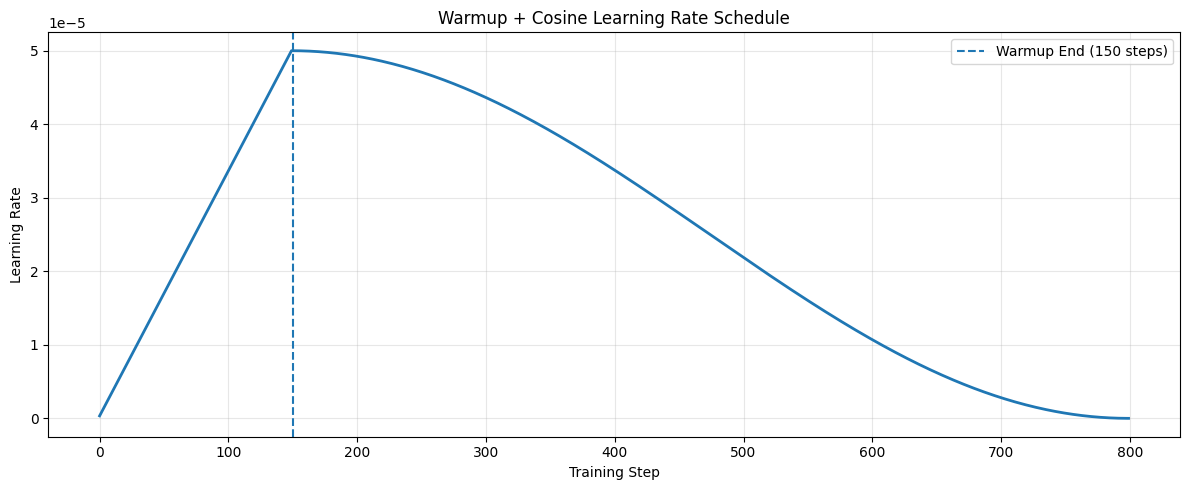

Initial LR                 : 3.33e-07
LR at warmup end (step 150) : 5.00e-05
Final LR (step 800)          : 0.00e+00

✓ Learning rate schedule demonstrated successfully!



In [ ]:
# ============================================================
# Warmup + Cosine Decay Scheduler
# ============================================================

class WarmupCosineScheduler:
    """
    Learning rate scheduler with linear warmup
    followed by cosine decay.
    """

    def __init__(self, optimizer, warmup_steps, total_steps, initial_lr=5e-5):
        self.optimizer = optimizer
        self.warmup_steps = max(1, warmup_steps)
        self.total_steps = max(self.warmup_steps + 1, total_steps)
        self.initial_lr = initial_lr
        self.current_step = 0

    def step(self):
        """Advance one step and update learning rate."""
        self.current_step += 1

        # ----------------------------------------------------
        # Linear Warmup Phase
        # ----------------------------------------------------
        if self.current_step <= self.warmup_steps:
            lr = self.initial_lr * (self.current_step / self.warmup_steps)

        # ----------------------------------------------------
        # Cosine Decay Phase
        # ----------------------------------------------------
        else:
            progress = (
                (self.current_step - self.warmup_steps)
                / (self.total_steps - self.warmup_steps)
            )

            progress = min(max(progress, 0.0), 1.0)  # Clamp to [0,1]

            lr = self.initial_lr * 0.5 * (1 + np.cos(np.pi * progress))

        for group in self.optimizer.param_groups:
            group["lr"] = lr

        return lr


# ============================================================
# Demonstration
# ============================================================

print("=" * 70)
print("EXERCISE 5.1: LEARNING RATE WARMUP + COSINE DECAY")
print("=" * 70)

demo_initial_lr = 5e-5
demo_optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=demo_initial_lr
)

warmup_steps = 150
total_steps = 800

scheduler = WarmupCosineScheduler(
    demo_optimizer,
    warmup_steps=warmup_steps,
    total_steps=total_steps,
    initial_lr=demo_initial_lr
)

lrs = []
for _ in range(total_steps):
    lr = scheduler.step()
    lrs.append(lr)


# ============================================================
# Plot Schedule
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(lrs, linewidth=2)
plt.axvline(
    warmup_steps,
    linestyle="--",
    label=f"Warmup End ({warmup_steps} steps)"
)

plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.title("Warmup + Cosine Learning Rate Schedule")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lr_schedule.png", dpi=200, bbox_inches="tight")
plt.show()


print(f"Initial LR                 : {lrs[0]:.2e}")
print(f"LR at warmup end (step {warmup_steps}) : {lrs[warmup_steps-1]:.2e}")
print(f"Final LR (step {total_steps})          : {lrs[-1]:.2e}")

print("\n✓ Learning rate schedule demonstrated successfully!\n")


### Exercise 5.2: Analyzing Sampling Strategy Effects

In [ ]:
# ============================================================
# EXERCISE 5.2: Sampling Strategy Analysis
# ============================================================

print("=" * 70)
print("EXERCISE 5.2: SAMPLING STRATEGY ANALYSIS")
print("=" * 70)
print("Generating multiple samples to analyze variability:\n")

start_context = "Machine learning"
max_tokens = 35
num_samples = 3

model.eval()
context_size = model.pos_emb.weight.size(0)

encoded_context = text_to_token_ids(start_context, tokenizer).to(device)

strategies = {
    "Greedy":        {"temperature": 0.0, "top_k": None},
    "Temp 0.7":      {"temperature": 0.7, "top_k": None},
    "Temp 1.2":      {"temperature": 1.2, "top_k": None},
    "Top-k 10":      {"temperature": 1.0, "top_k": 10},
    "Top-k 50":      {"temperature": 1.0, "top_k": 50},
}

print(f"Context: '{start_context}'")
print(f"Samples per strategy: {num_samples}")
print(f"New tokens per sample: {max_tokens}\n")

# ------------------------------------------------------------
# Sampling Loop
# ------------------------------------------------------------

for strategy_name, params in strategies.items():

    print(f"\n--- {strategy_name} ---")

    for i in range(num_samples):

        torch.manual_seed(100 + i)

        output_ids = generate(
            model=model,
            idx=encoded_context.clone(),
            max_new_tokens=max_tokens,
            context_size=context_size,
            temperature=params["temperature"],
            top_k=params["top_k"],
        )

        generated_text = token_ids_to_text(output_ids, tokenizer)

        # Compact display
        preview = (
            generated_text[:100] + "..."
            if len(generated_text) > 100
            else generated_text
        )

        print(f"  {i+1}. {preview}")


# ============================================================
# Observations
# ============================================================

print("\n" + "=" * 70)
print("ANALYSIS")
print("=" * 70)
print("• Greedy decoding is deterministic — identical output each run.")
print("• Temperature sampling introduces randomness.")
print("• Higher temperature increases diversity but may reduce coherence.")
print("• Top-k restricts token choices to highest-probability candidates.")
print("• Practical balance: temperature 0.7–1.0 with top-k 30–50.")
print("=" * 70 + "\n")

EXERCISE 5.2: SAMPLING STRATEGY ANALYSIS
Generating multiple samples to analyze variability:

Context: 'Machine learning'
Samples per strategy: 3
New tokens per sample: 35


--- Greedy ---
  1. Machine learning he had been through, and in spite of, his pictures--so handsome, so charming, so di...
  2. Machine learning he had been through, and in spite of, his pictures--so handsome, so charming, so di...
  3. Machine learning he had been through, and in spite of, his pictures--so handsome, so charming, so di...

--- Temp 0.7 ---
  1. Machine learning he had always suspected you of across the picture was one of Jack's "There were ref...
  2. Machine learning him deprecatingperson to haveI must ( _rs_ drawing-rooms with equ.


"Oh, as audac'...
  3. Machine learning plain oak panelling of the dark.

"Oh, struck by his last word.


"Don't, he said w...

--- Temp 1.2 ---
  1. Machine learning vibrant stingborgh false such fired across tone proportess Cannon queer serve him, ...
  2. Machine

### Exercise 5.3: Impact of Batch Size on Training Dynamics

In [ ]:
print("=" * 70)
print("EXERCISE 5.3: BATCH SIZE EFFECTS ON TRAINING")
print("=" * 70)
print("Analyzing how batch size affects training dynamics:\n")

# ------------------------------------------------------------
# Batch Sizes to Compare
# ------------------------------------------------------------

batch_sizes_to_test = [1, 2, 4, 8]

print(f"{'Batch Size':<12} {'Batches/Epoch':<18} {'Est. Memory / Forward':<25}")
print("-" * 70)

embedding_dim = GPT_CONFIG_124M["emb_dim"]

for bs in batch_sizes_to_test:
    try:
        temp_loader = create_dataloader_v1(
            train_data,
            batch_size=bs,
            max_length=max_length,
            stride=stride,
            shuffle=True,
            drop_last=True
        )

        num_batches = len(temp_loader)

        # Rough forward-pass memory estimate (activations only)
        tokens_per_batch = bs * max_length
        memory_mb = tokens_per_batch * embedding_dim * 4 / 1e6  # float32

        print(f"{bs:<12} {num_batches:<18} ~{memory_mb:>8.1f} MB")

    except Exception as e:
        print(f"{bs:<12} Error: {str(e)[:50]}")


print("\n" + "=" * 70)
print("BATCH SIZE ANALYSIS")
print("=" * 70)

print("""
Small Batches (1–2)
  + More parameter updates per epoch
  + Noisy gradients may improve generalization
  + Lower GPU memory usage
  - Higher gradient variance
  - Often require lower learning rates

Medium Batches (4–8)
  + Balanced gradient stability
  + Better hardware utilization
  + Common choice for experimentation

Large Batches (16+)
  + Very stable gradient estimates
  + Supports larger learning rates (linear scaling rule)
  - Higher memory consumption
  - Fewer updates per epoch
  - Risk of sharper minima / poorer generalization

Practical Recommendations:
  • Start with batch size 2–4 for small datasets
  • Increase batch size with proportional LR scaling
  • Use gradient accumulation if memory constrained
  • Always monitor validation loss for overfitting
""")

print("=" * 70 + "\n")


EXERCISE 5.3: BATCH SIZE EFFECTS ON TRAINING
Analyzing how batch size affects training dynamics:

Batch Size   Batches/Epoch      Est. Memory / Forward    
----------------------------------------------------------------------
1            27                 ~     1.0 MB
2            13                 ~     2.0 MB
4            6                  ~     3.9 MB
8            3                  ~     7.9 MB

BATCH SIZE ANALYSIS

Small Batches (1–2)
  + More parameter updates per epoch
  + Noisy gradients may improve generalization
  + Lower GPU memory usage
  - Higher gradient variance
  - Often require lower learning rates

Medium Batches (4–8)
  + Balanced gradient stability
  + Better hardware utilization
  + Common choice for experimentation

Large Batches (16+)
  + Very stable gradient estimates
  + Supports larger learning rates (linear scaling rule)
  - Higher memory consumption
  - Fewer updates per epoch
  - Risk of sharper minima / poorer generalization

Practical Recommendations

### Exercise 5.4: Gradient Accumulation for Larger Effective Batch Size

In [ ]:
print("=" * 70)
print("EXERCISE 5.4: GRADIENT ACCUMULATION")
print("=" * 70)


def train_with_gradient_accumulation(
    model,
    train_loader,
    optimizer,
    device,
    accumulation_steps=4,
    num_update_steps=20,
):
    """
    Gradient accumulation training loop.

    Effective batch size = batch_size * accumulation_steps
    """

    model.train()

    optimizer.zero_grad()

    total_loss = 0.0
    update_step = 0
    accumulation_counter = 0

    for input_batch, target_batch in train_loader:

        if update_step >= num_update_steps:
            break

        # Forward
        loss = calc_loss_batch(input_batch, target_batch, model, device)

        # Normalize loss to simulate larger batch
        scaled_loss = loss / accumulation_steps
        scaled_loss.backward()

        accumulation_counter += 1
        total_loss += loss.item()

        # Perform optimizer step after accumulation
        if accumulation_counter == accumulation_steps:
            optimizer.step()
            optimizer.zero_grad()

            update_step += 1
            accumulation_counter = 0

            if update_step % 5 == 0:
                avg_so_far = total_loss / update_step
                print(f"  Update Step {update_step:02d} | Avg Loss: {avg_so_far:.4f}")

    # Handle leftover gradients (if loop ends mid-accumulation)
    if accumulation_counter > 0:
        optimizer.step()
        optimizer.zero_grad()
        update_step += 1

    return total_loss / max(update_step, 1)


# ------------------------------------------------------------
# Concept Explanation
# ------------------------------------------------------------

print("\nGradient Accumulation Concept:")
print("-" * 70)
print("""
Without gradient accumulation:
  - Batch size = 2
  - 1 update per batch

With accumulation_steps = 4:
  - Batch size = 2
  - Effective batch size = 8
  - 1 update per 4 batches
  - Gradients summed before update
""")


# ------------------------------------------------------------
# Demonstration
# ------------------------------------------------------------

print("\nDemonstrating gradient accumulation...")
print("-" * 70)

demo_model = GPTModel(GPT_CONFIG_124M).to(device)
demo_optimizer = torch.optim.AdamW(
    demo_model.parameters(),
    lr=8e-5
)

avg_loss = train_with_gradient_accumulation(
    model=demo_model,
    train_loader=train_loader,
    optimizer=demo_optimizer,
    device=device,
    accumulation_steps=4,
    num_update_steps=12
)

print(f"\nFinal Average Loss: {avg_loss:.4f}")

print("\n" + "=" * 70)
print("BENEFITS OF GRADIENT ACCUMULATION")
print("=" * 70)
print("""
• Enables larger effective batch sizes without increasing memory usage
• Produces smoother gradient estimates
• Essential for training large models on limited GPUs
• Works well with cosine LR scaling strategies

When to use:
• Memory constrained environments
• Large models
• When scaling batch size improves stability
""")
print("=" * 70 + "\n")


# Cleanup
del demo_model, demo_optimizer

EXERCISE 5.4: GRADIENT ACCUMULATION

Gradient Accumulation Concept:
----------------------------------------------------------------------

Without gradient accumulation:
  - Batch size = 2
  - 1 update per batch

With accumulation_steps = 4:
  - Batch size = 2
  - Effective batch size = 8
  - 1 update per 4 batches
  - Gradients summed before update


Demonstrating gradient accumulation...
----------------------------------------------------------------------


NameError: name 'GPTModel' is not defined